In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import KBinsDiscretizer

from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BIC

from pgmpy.models import BayesianNetwork

In [6]:
data_path = "../data/samples/selected_features_50k.csv"

df = pd.read_csv(data_path)

print(df.shape)

df.head()

(50000, 31)


,Bwd Packet Length Max,Flow IAT Std,Destination Port,Total Length of Fwd Packets,Init_Win_bytes_backward,Bwd Packets/s,Flow Packets/s,Total Fwd Packets,Flow IAT Mean,Fwd Header Length,...,Active Mean,Active Min,Bwd IAT Total,Active Max,Bwd IAT Mean,Bwd IAT Max,Down/Up Ratio,Flow IAT Min,Bwd IAT Std,Label
0,1231.0,3.632447e+06,443.0,13132.0,661.0,0.331705,0.603873,32.0,1.679633e+06,1032.0,...,677642.6364,36136.0,118000000.0,7089918.0,3.093099e+06,10000000.0,1.0,3.0,4.513024e+06,0
1,1460.0,3.377168e+04,443.0,376.0,60.0,25.862114,62.069073,7.0,1.757573e+04,152.0,...,0.0000,0.0,90738.0,0.0,2.268450e+04,87925.0,0.0,40.0,4.350851e+04,0
2,773.0,4.491948e+04,443.0,843.0,5186.0,18.361089,41.312451,10.0,2.562965e+04,332.0,...,0.0000,0.0,283531.0,0.0,4.050443e+04,152808.0,0.0,1.0,6.791098e+04,0
3,144.0,1.651222e+02,53.0,60.0,-1.0,6920.415225,13840.830450,2.0,9.633333e+01,40.0,...,0.0000,0.0,1.0,0.0,1.000000e+00,1.0,1.0,1.0,0.000000e+00,0
4,202.0,0.000000e+00,53.0,58.0,-1.0,3.966224,7.932447,1.0,2.521290e+05,32.0,...,0.0000,0.0,0.0,0.0,0.000000e+00,0.0,1.0,252129.0,0.000000e+00,0


In [7]:
X = df.drop("Label", axis=1)

y = df["Label"]

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = importances.sort_values(
    ascending=False
).head(12).index

print("Selected DAG features:")

print(top_features)

Selected DAG features:
Index(['Bwd Packet Length Max', 'Total Length of Fwd Packets',
       'Destination Port', 'Flow IAT Std', 'Flow Packets/s',
       'Total Fwd Packets', 'Flow IAT Mean', 'Init_Win_bytes_backward',
       'Fwd Header Length', 'Fwd Packet Length Mean', 'Fwd Packet Length Max',
       'Init_Win_bytes_forward'],
      dtype='object')


In [21]:
X_reduced = X[top_features]

print("Reduced dataset shape:", X_reduced.shape)

Reduced dataset shape: (50000, 12)


In [22]:
discretizer = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile"
)

X_discrete = discretizer.fit_transform(X_reduced)

X_discrete = pd.DataFrame(
    X_discrete,
    columns=X_reduced.columns
)

X_discrete["Label"] = y.values

X_discrete.head()

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_discre

,Bwd Packet Length Max,Total Length of Fwd Packets,Destination Port,Flow IAT Std,Flow Packets/s,Total Fwd Packets,Flow IAT Mean,Init_Win_bytes_backward,Fwd Header Length,Fwd Packet Length Mean,Fwd Packet Length Max,Init_Win_bytes_forward,Label
0,2.0,4.0,3.0,3.0,0.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,0
1,3.0,3.0,3.0,2.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,0
2,2.0,4.0,3.0,2.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,0
3,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0,1.0,2.0,1.0,0.0,0
4,2.0,2.0,1.0,0.0,1.0,0.0,3.0,0.0,1.0,4.0,3.0,0.0,0


In [33]:
import pickle

with open("../models/discretizer.pkl", "wb") as f:
    pickle.dump(discretizer, f)

In [41]:
with open("../models/top_features.pkl", "wb") as f:
    pickle.dump(list(top_features), f)

DAG learning with Domain Constraints


In [68]:
from pgmpy.estimators import HillClimbSearch, BIC, ExpertKnowledge

forbidden_edges = [
    ("Label", col)
    for col in X_discrete.columns
    if col != "Label"
]

expert = ExpertKnowledge(
    forbidden_edges=forbidden_edges
)

hc = HillClimbSearch(X_discrete)

best_model = hc.estimate(
    scoring_method=BIC(X_discrete),
    expert_knowledge=expert,
    max_indegree=3
)

print("DAG learned with domain constraints")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fr

  0%|          | 0/1000000 [00:00<?, ?it/s]

DAG learned with domain constraints


Dag Stability Testing

In [64]:
from collections import Counter

parent_sets = []

for i in range(10):

    sample = X_discrete.sample(
        frac=0.8,
        replace=True,
        random_state=i
    )

    hc = HillClimbSearch(sample)

    model = hc.estimate(
        scoring_method=BIC(sample),
        max_indegree=3
    )

    parents = tuple(sorted(model.get_parents("Label")))

    parent_sets.append(parents)

print("Bootstrap parent sets:")
print(parent_sets)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fr

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fr

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fr

...

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fr

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fr

  0%|          | 0/1000000 [00:00<?, ?it/s]

Bootstrap parent sets:
[('Init_Win_bytes_forward',), ('Destination Port', 'Init_Win_bytes_backward', 'Total Fwd Packets'), (), ('Destination Port', 'Init_Win_bytes_backward', 'Total Fwd Packets'), ('Destination Port', 'Init_Win_bytes_backward', 'Total Fwd Packets'), ('Destination Port', 'Init_Win_bytes_backward', 'Total Fwd Packets'), ('Init_Win_bytes_forward',), ('Flow IAT Mean', 'Total Fwd Packets'), (), ('Destination Port', 'Init_Win_bytes_backward', 'Total Fwd Packets')]


Computing Stability Score

In [65]:
counts = Counter(parent_sets)

print("\nParent frequency:")

for k,v in counts.items():
    print(k, ":", v)

stability = max(counts.values()) / 10

print("\nDAG Stability Score:", round(stability,2))


Parent frequency:
('Init_Win_bytes_forward',) : 2
('Destination Port', 'Init_Win_bytes_backward', 'Total Fwd Packets') : 5
() : 2
('Flow IAT Mean', 'Total Fwd Packets') : 1

DAG Stability Score: 0.5


In [55]:
print("Learned DAG edges:")

print(best_model.edges())

Learned DAG edges:
[('Bwd Packet Length Max', 'Fwd Packet Length Max'), ('Total Length of Fwd Packets', 'Total Fwd Packets'), ('Total Length of Fwd Packets', 'Init_Win_bytes_forward'), ('Total Length of Fwd Packets', 'Fwd Packet Length Mean'), ('Destination Port', 'Init_Win_bytes_forward'), ('Destination Port', 'Bwd Packet Length Max'), ('Destination Port', 'Init_Win_bytes_backward'), ('Destination Port', 'Fwd Packet Length Max'), ('Destination Port', 'Total Length of Fwd Packets'), ('Destination Port', 'Label'), ('Flow Packets/s', 'Flow IAT Std'), ('Flow Packets/s', 'Destination Port'), ('Flow Packets/s', 'Init_Win_bytes_backward'), ('Flow Packets/s', 'Bwd Packet Length Max'), ('Total Fwd Packets', 'Fwd Header Length'), ('Total Fwd Packets', 'Flow IAT Std'), ('Total Fwd Packets', 'Label'), ('Flow IAT Mean', 'Flow Packets/s'), ('Flow IAT Mean', 'Total Length of Fwd Packets'), ('Flow IAT Mean', 'Fwd Packet Length Max'), ('Flow IAT Mean', 'Destination Port'), ('Init_Win_bytes_backward', 

In [56]:
from pgmpy.models import DiscreteBayesianNetwork

model = DiscreteBayesianNetwork(best_model.edges())

In [57]:
model.fit(X_discrete)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Bwd Packet Length Max': 'N', 'Total Length of Fwd Packets': 'N', 'Destination Port': 'N', 'Flow IAT Std': 'N', 'Flow Packets/s': 'N', 'Total Fwd Packets': 'N', 'Flow IAT Mean': 'N', 'Init_Win_bytes_backward': 'N', 'Fwd Header Length': 'N', 'Fwd Packet Length Mean': 'N', 'Fwd Packet Length Max': 'N', 'Init_Win_bytes_forward': 'N', 'Label': 'N'}


In [58]:
parents = model.get_parents("Label")

print("Causal parents of attack:")

print(parents)

Causal parents of attack:
['Destination Port', 'Total Fwd Packets', 'Init_Win_bytes_backward']


Featre Reduction Report

In [66]:
original_features = 78
selected_features = len(df.columns) - 1
causal_features_count = len(causal_features)

print("Original Features:", original_features)
print("Selected Features:", selected_features)
print("Causal Features:", causal_features_count)

reduction = (1 - causal_features_count/original_features) * 100

print("Feature Reduction:", round(reduction,2), "%")

Original Features: 78
Selected Features: 30
Causal Features: 3
Feature Reduction: 96.15 %


In [59]:
with open("../models/causal_dag.pkl", "wb") as f:
    pickle.dump(model, f)

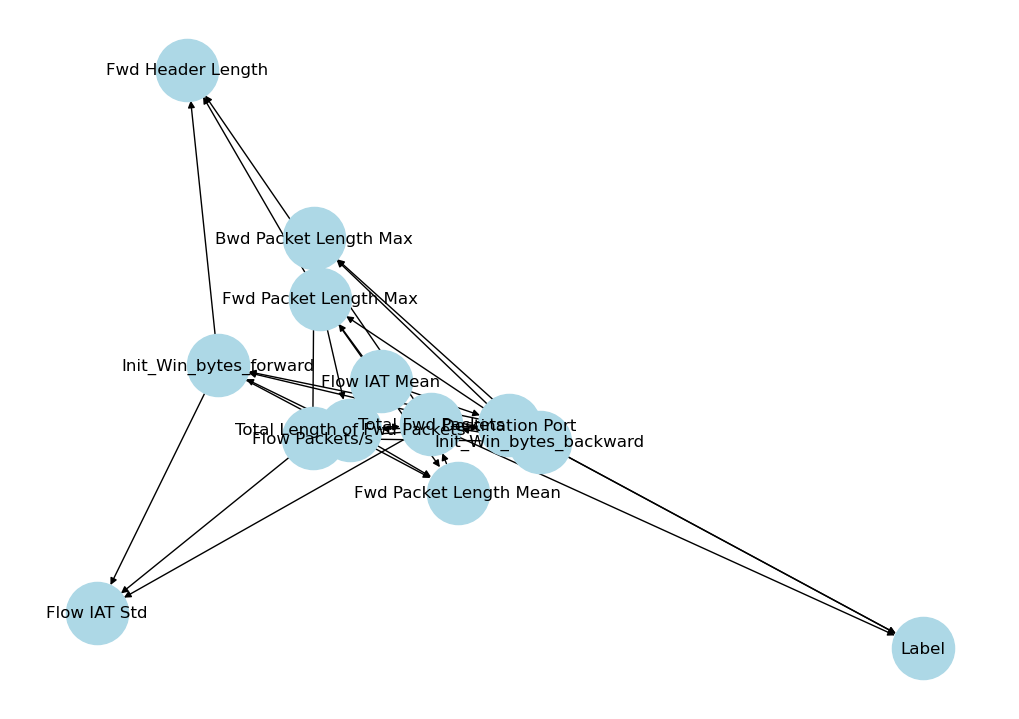

In [60]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph(best_model.edges())

plt.figure(figsize=(10,7))
nx.draw(G, with_labels=True, node_size=2000, node_color="lightblue")
plt.show()

In [40]:
model.get_parents("Label")

['Destination Port', 'Total Fwd Packets', 'Init_Win_bytes_backward']

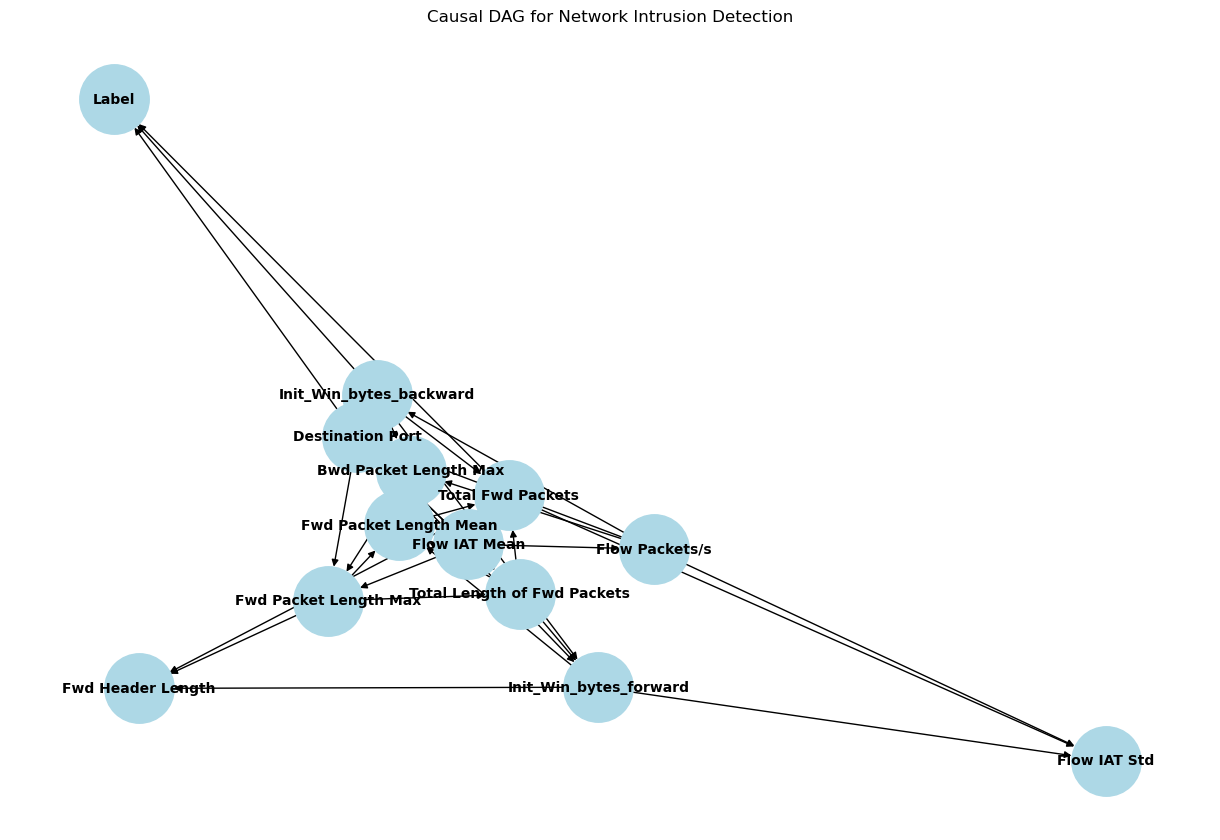

In [61]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph(best_model.edges())

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=True
)

plt.title("Causal DAG for Network Intrusion Detection")

plt.savefig("../diagrams/causal_dag.png", dpi=300)

plt.show()

Shows Full Causal Discovery

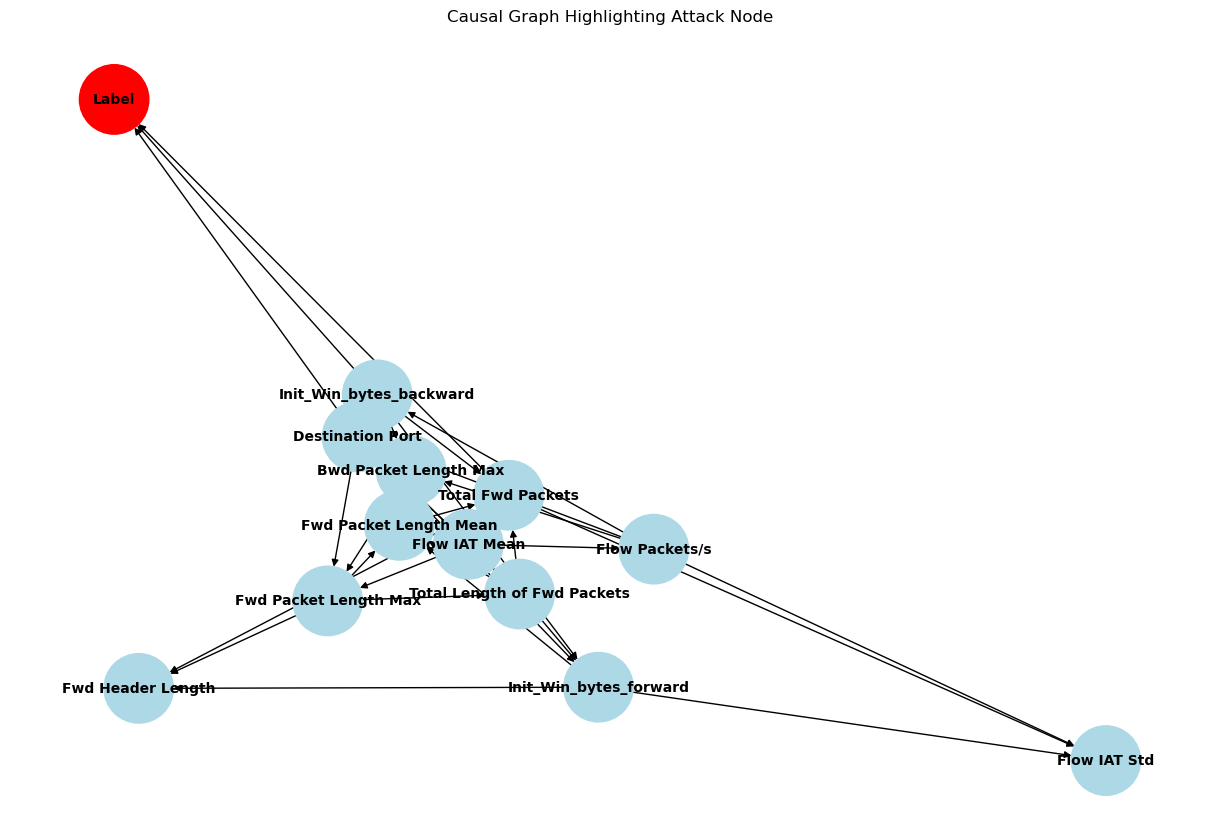

In [62]:
plt.figure(figsize=(12,8))

node_colors = []

for node in G.nodes():
    if node == "Label":
        node_colors.append("red")
    else:
        node_colors.append("lightblue")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color=node_colors,
    font_size=10,
    font_weight="bold",
    arrows=True
)

plt.title("Causal Graph Highlighting Attack Node")

plt.savefig("../diagrams/causal_dag_highlighted.png", dpi=300)

plt.show()

Shoes Interpretable Causal Drivers

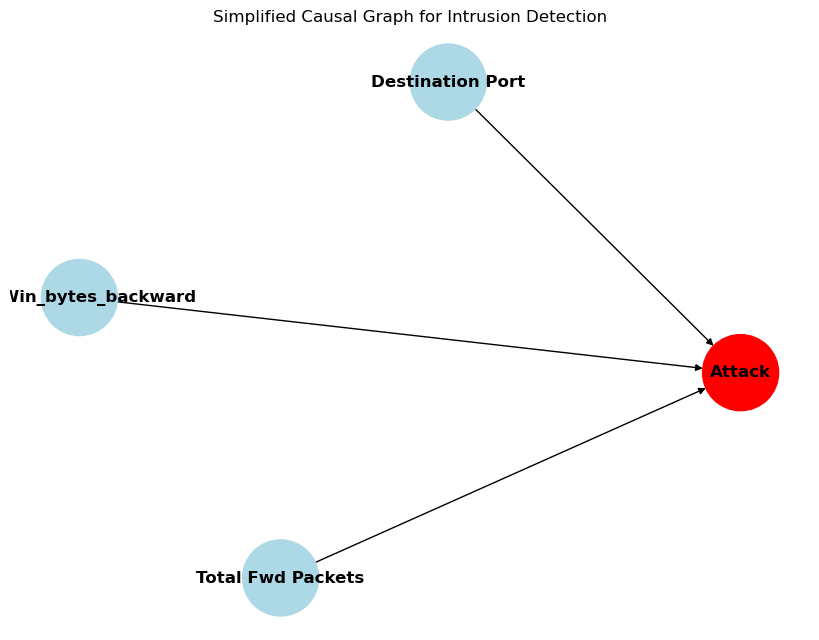

In [47]:
import networkx as nx
import matplotlib.pyplot as plt

# causal parents
causal_features = [
    "Destination Port",
    "Total Fwd Packets",
    "Init_Win_bytes_backward"
]

edges = [(feature, "Attack") for feature in causal_features]

G = nx.DiGraph(edges)

plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

node_colors = ["red" if node=="Attack" else "lightblue" for node in G.nodes()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color=node_colors,
    font_size=12,
    font_weight="bold",
    arrows=True
)

plt.title("Simplified Causal Graph for Intrusion Detection")

plt.show()